<a href="https://colab.research.google.com/github/darig7w7/ProyectoSaludMental/blob/main/SaludMental.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Librerias**

In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import IsolationForest
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# **Carga de datos**

In [49]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [50]:
df = pd.read_csv('/content/drive/MyDrive/Ciencia de datos/Programación Ciencia de Datos/survey.csv')

# **Descripción de datos**
* **Age**: Edad del encuestado (campo numérico).
* **Gender**: Género del encuestado (campo de texto libre).
* **Country**: País de residencia.
* **state**: Si vive en los Estados Unidos, ¿en qué estado o territorio reside?
* **self_employed**: ¿Es trabajador independiente?
* **family_history**: ¿Tiene antecedentes familiares de enfermedades mentales?
* **treatment**: ¿Ha buscado tratamiento para una condición de salud mental? **(Variable Objetivo)**.
* **work_interfere**: Si tiene una condición de salud mental, ¿siente que esta interfiere con su trabajo?
* **no_employees**: ¿Cuántos empleados tiene su empresa u organización?
* **remote_work**: ¿Trabaja de forma remota al menos el 50% del tiempo?
* **tech_company**: ¿Es su empleador principalmente una empresa tecnológica?
* **benefits**: ¿Su empleador ofrece beneficios de salud mental?
* **care_options**: ¿Conoce las opciones de atención de salud mental que ofrece su empleador?
* **wellness_program**: ¿Su empleador ha discutido la salud mental como parte de un programa de bienestar?
* **seek_help**: ¿Su empleador ofrece recursos para aprender sobre salud mental y cómo buscar ayuda?
* **anonymity**: ¿Se protege su anonimato si decide utilizar recursos de tratamiento?
* **leave**: ¿Qué tan fácil es solicitar una licencia médica por una condición de salud mental?
* **mental_health_consequence**: ¿Cree que discutir un problema de salud mental con su empleador tendría consecuencias negativas?
* **phys_health_consequence**: ¿Cree que discutir un problema de salud física con su empleador tendría consecuencias negativas?
* **coworkers**: ¿Estaría dispuesto a discutir un problema de salud mental con sus compañeros de trabajo?
* **phys_health_interview**: ¿Mencionaría un problema de salud física con un posible empleador en una entrevista?
* **mental_vs_physical**: ¿Siente que su empleador toma la salud mental tan en serio como la salud física?
* **obs_consequence**: ¿Ha oído hablar o ha observado consecuencias negativas para compañeros con condiciones de salud mental en su lugar de trabajo?
* **comments**: Cualquier nota o comentario adicional.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1259 entries, 0 to 1258
Data columns (total 27 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Timestamp                  1259 non-null   object
 1   Age                        1259 non-null   int64 
 2   Gender                     1259 non-null   object
 3   Country                    1259 non-null   object
 4   state                      744 non-null    object
 5   self_employed              1241 non-null   object
 6   family_history             1259 non-null   object
 7   treatment                  1259 non-null   object
 8   work_interfere             995 non-null    object
 9   no_employees               1259 non-null   object
 10  remote_work                1259 non-null   object
 11  tech_company               1259 non-null   object
 12  benefits                   1259 non-null   object
 13  care_options               1259 non-null   object
 14  wellness

In [51]:
CATS = {
    'Gender':                    None,
    'self_employed':             None,
    'family_history':            None,
    'treatment':                 None,
    'work_interfere':            ['Never','Rarely','Sometimes','Often','Unknown'],
    'no_employees':              ['1-5','6-25','26-100','100-500','500-1000','More than 1000'],
    'remote_work':               None,
    'tech_company':              None,
    'benefits':                  None,
    'care_options':              None,
    'wellness_program':          None,
    'seek_help':                 None,
    'anonymity':                 None,
    'leave':                     ['Very easy','Somewhat easy','Don\'t know','Somewhat difficult','Very difficult'],
    'mental_health_consequence': None,
    'phys_health_consequence':   None,
    'coworkers':                 None,
    'supervisor':                None,
    'mental_health_interview':   None,
    'phys_health_interview':     None,
    'mental_vs_physical':        None,
    'obs_consequence':           None,
}

In [52]:
TITULOS = {
    'Gender':                    'Género',
    'self_employed':             '¿Trabaja de forma independiente?',
    'family_history':            '¿Tiene historial familiar de enfermedad mental?',
    'treatment':                 '¿Buscó tratamiento de salud mental?',
    'work_interfere':            '¿La condición mental interfiere con el trabajo?',
    'no_employees':              'Tamaño de la empresa (N° empleados)',
    'remote_work':               '¿Trabaja de forma remota al menos 50%?',
    'tech_company':              '¿El empleador es una empresa tech?',
    'benefits':                  '¿El empleador ofrece beneficios de salud mental?',
    'care_options':              '¿Conoce las opciones de cuidado mental del empleador?',
    'wellness_program':          '¿El empleador tiene programa de bienestar?',
    'seek_help':                 '¿El empleador ofrece recursos para buscar ayuda?',
    'anonymity':                 '¿El anonimato está protegido?',
    'leave':                     '¿Qué tan fácil es tomar licencia por salud mental?',
    'mental_health_consequence': '¿Hablar de salud mental tendría consecuencias negativas?',
    'phys_health_consequence':   '¿Hablar de salud física tendría consecuencias negativas?',
    'coworkers':                 '¿Hablaría de salud mental con sus compañeros?',
    'supervisor':                '¿Hablaría de salud mental con su supervisor?',
    'mental_health_interview':   '¿Mencionaría salud mental en una entrevista?',
    'phys_health_interview':     '¿Mencionaría salud física en una entrevista?',
    'mental_vs_physical':        '¿El empleador toma igual en serio salud mental y física?',
    'obs_consequence':           '¿Ha visto consecuencias negativas para compañeros?',
}

def graficar_variables(df, titulo_seccion=""):
    if titulo_seccion:
        print(f"\n{'='*40}\n{titulo_seccion}\n{'='*40}")
    for col, orden in CATS.items():
        if col not in df.columns:
            continue
        counts = df[col].value_counts()
        if orden:
            counts = counts.reindex([o for o in orden if o in counts.index])

        fig, ax = plt.subplots(figsize=(6, 3.5))
        colors = COLORES[:len(counts)]
        ax.bar(counts.index, counts.values, color=colors, edgecolor='white', linewidth=1.5)
        for i, (_, v) in enumerate(counts.items()):
            ax.text(i, v + counts.max() * 0.02, str(v), ha='center', va='bottom', fontsize=9, fontweight='bold')
        ax.set_title(TITULOS.get(col, col), fontsize=11, fontweight='bold', pad=10)
        ax.set_ylabel('Frecuencia', fontsize=10)
        ax.set_ylim(0, counts.max() * 1.18)
        ax.tick_params(axis='x', labelsize=9, rotation=20)
        ax.set_facecolor('#F5F8FA')
        fig.patch.set_facecolor('#FFFFFF')
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.grid(axis='y', color='white', linewidth=1.2)
        plt.tight_layout()
        plt.show()

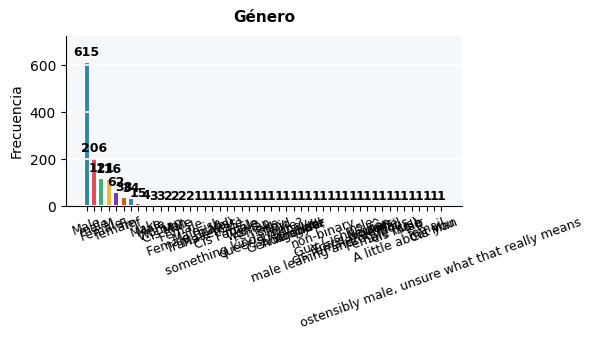

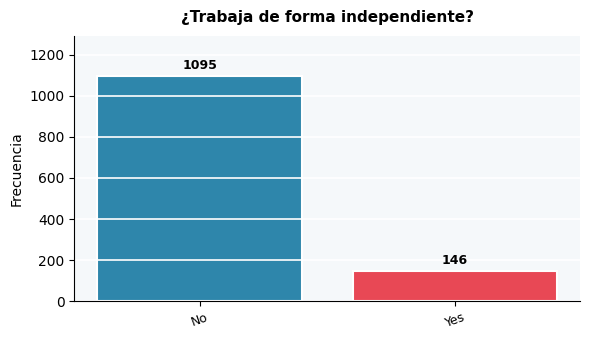

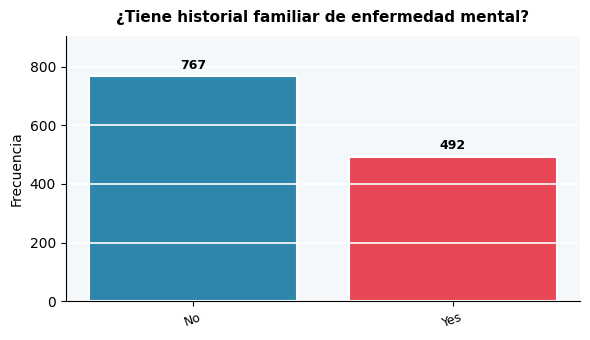

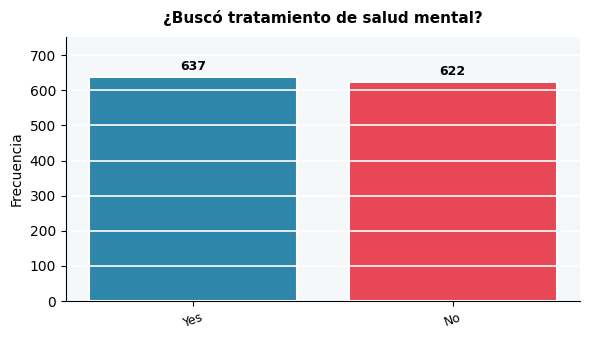

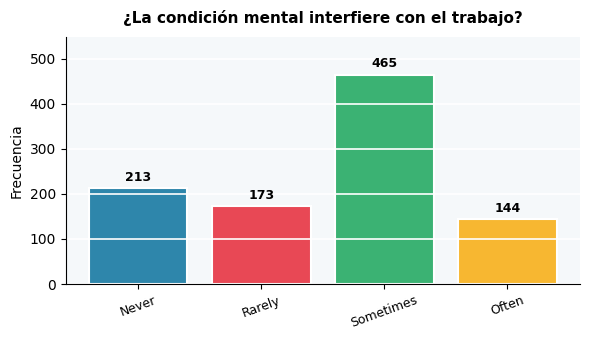

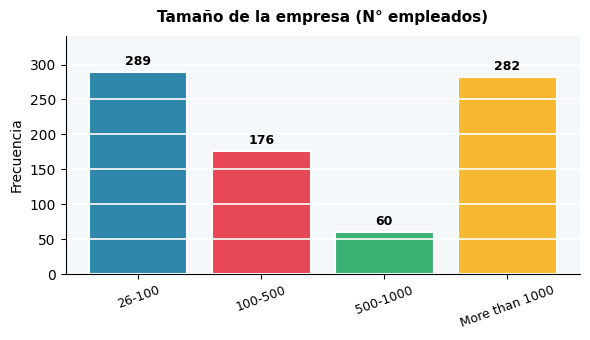

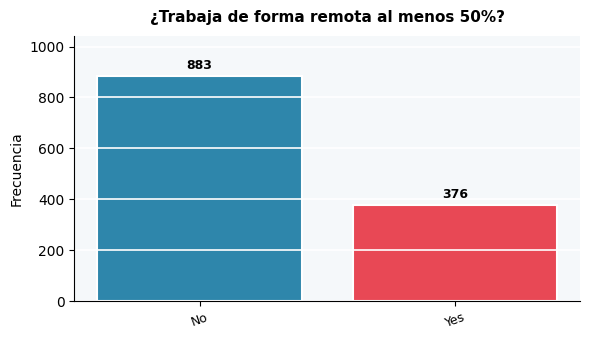

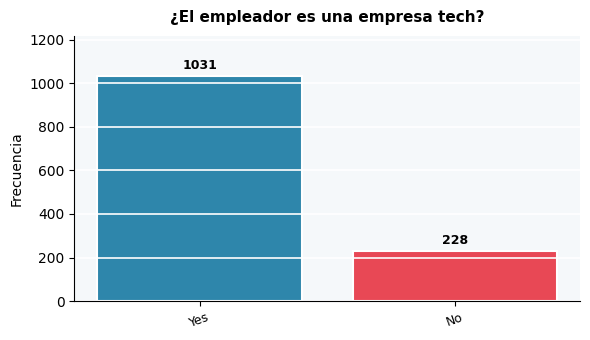

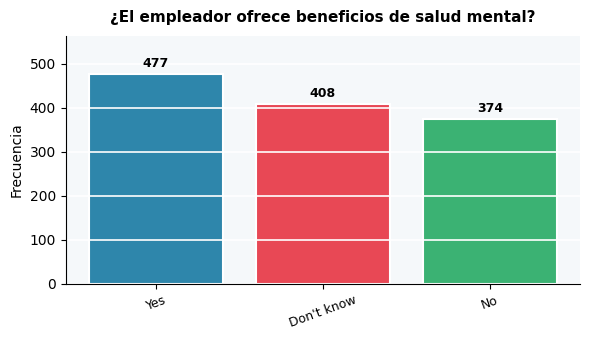

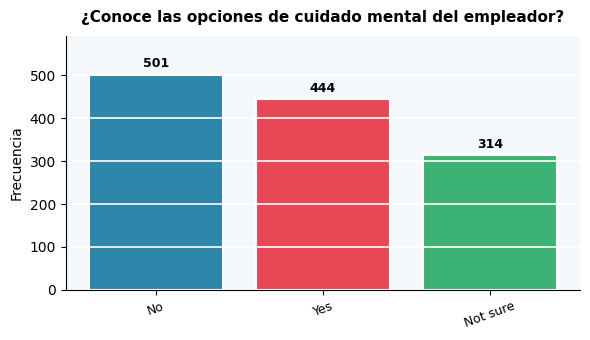

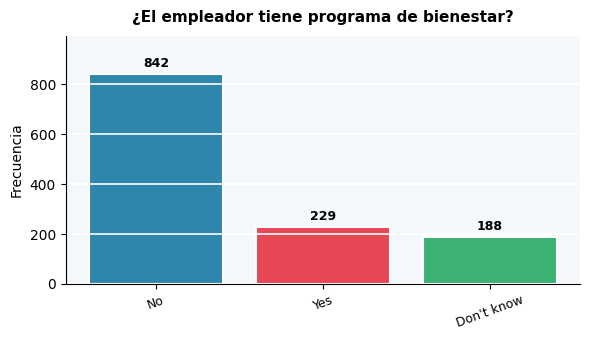

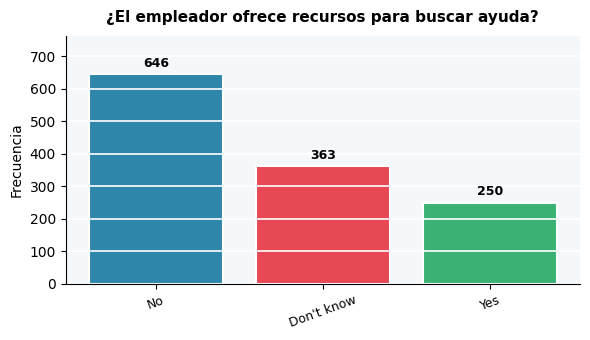

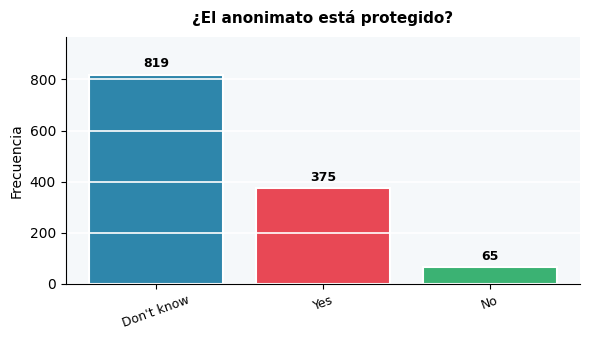

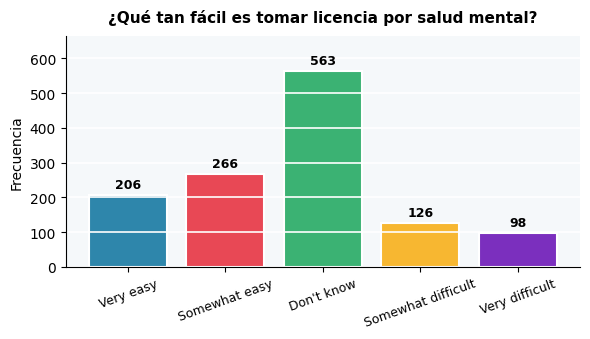

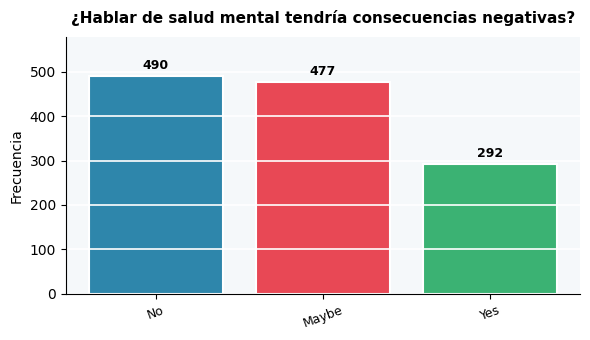

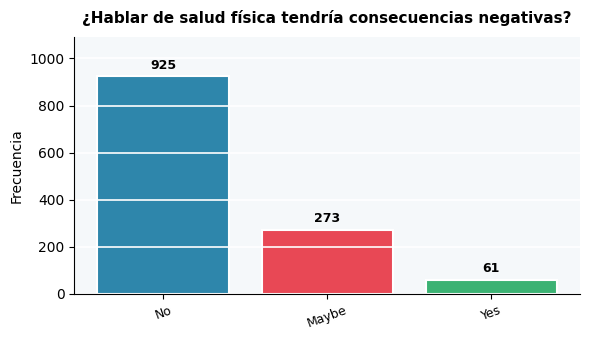

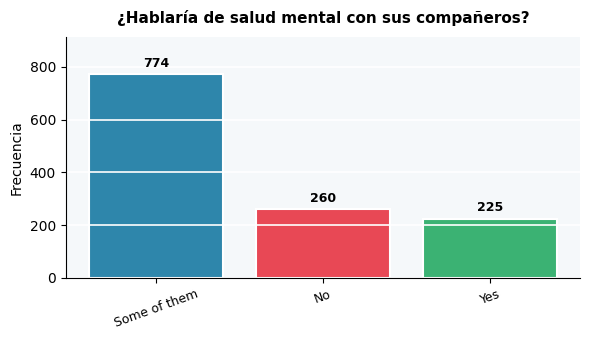

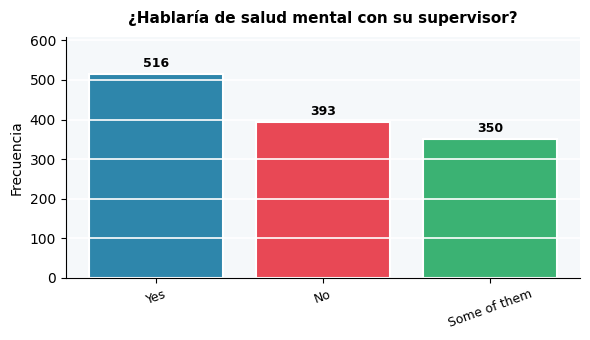

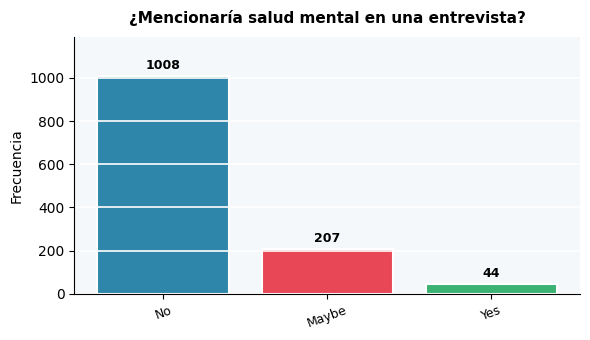

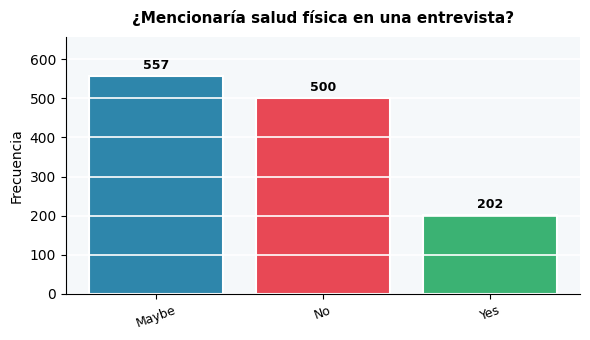

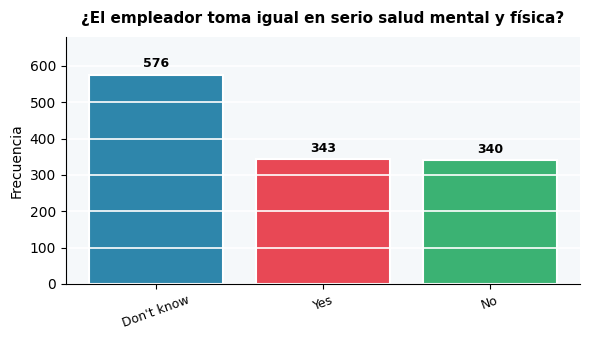

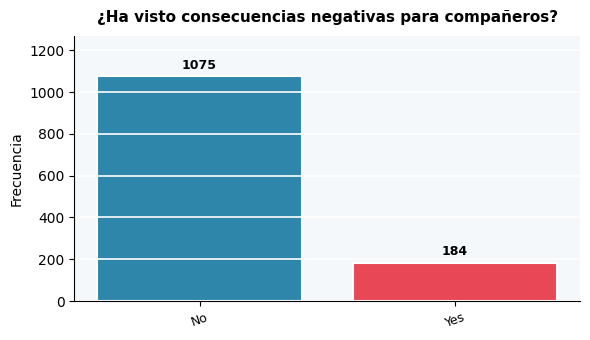

In [53]:
graficar_variables(df)

In [54]:
def graficar_edad(df, titulo="Distribución de Edad"):
    fig, ax = plt.subplots(figsize=(6, 3.5))
    ax.hist(df['Age'], bins=25, color='#2E86AB', edgecolor='white', linewidth=1.2)
    ax.axvline(df['Age'].median(), color='#E84855', lw=2, ls='--', label=f'Mediana = {int(df["Age"].median())}')
    ax.set_title(titulo, fontsize=13, fontweight='bold', pad=10)
    ax.set_xlabel('Edad'); ax.set_ylabel('Frecuencia')
    ax.set_facecolor('#F5F8FA'); fig.patch.set_facecolor('#FFFFFF')
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    ax.grid(axis='y', color='white', linewidth=1.2)
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.show()

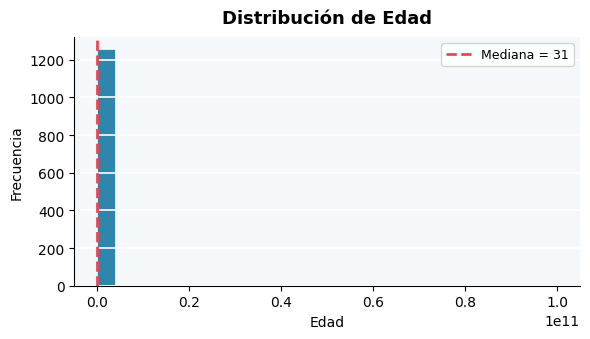

In [55]:
graficar_edad(df)

In [56]:
df.describe()

,Age
count,1.259000e+03
mean,7.942815e+07
std,2.818299e+09
min,-1.726000e+03
25%,2.700000e+01
50%,3.100000e+01
75%,3.600000e+01
max,1.000000e+11


# **Limpieza de datos**

---



## Limpieza de edad

In [57]:
mediana_edad = df.loc[(df['Age'] >= 15) & (df['Age'] <= 80), 'Age'].median()
df['Age'] = df['Age'].apply(lambda x: mediana_edad if not (15 <= x <= 80) else x)
df['Age'] = df['Age'].astype(int)
df.describe()

,Age
count,1259.000000
mean,32.069897
std,7.265565
min,18.000000
25%,27.000000
50%,31.000000
75%,36.000000
max,72.000000


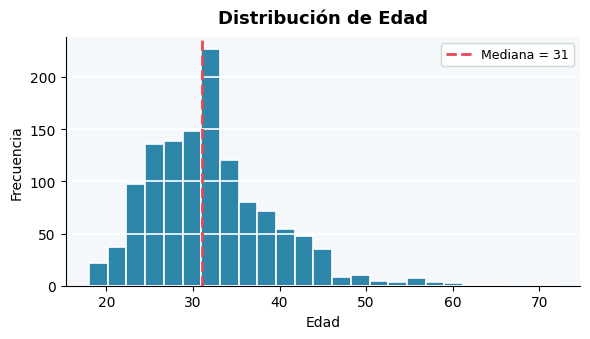

In [58]:
graficar_edad(df)

In [59]:
# LIMPIEZA DE GÉNERO
conteo = df['Gender'].value_counts()
pct    = df['Gender'].value_counts(normalize=True).mul(100).round(1)
tabla = pd.DataFrame({'cantidad': conteo, 'porcentaje %': pct})
tabla.head()

,cantidad,porcentaje %
Gender,,
Male,615,48.8
male,206,16.4
Female,121,9.6
M,116,9.2
female,62,4.9


In [60]:
def estandarizar_genero(g):
    g_clean = str(g).lower().strip()
    if g_clean in ['female', 'f', 'woman', 'femail', 'cis female',
                   'femake', 'female (trans)', 'trans woman', 'cis-female/femme']:
        return 'Female'
    if g_clean in ['male', 'm', 'man', 'make', 'cis male', 'mal', 'male-ish',
                   'maile', 'msle', 'mail', 'malr', 'cis man', 'fluid',
                   'something kinda male?', 'guy (-ish) ^_^']:
        return 'Male'
    return 'Other'

df['Gender'] = df['Gender'].apply(estandarizar_genero)

vectorizer = TfidfVectorizer(analyzer='char', ngram_range=(2, 3))

X_gen = vectorizer.fit_transform(df['Gender'].astype(str))
clf_iso = IsolationForest(contamination=0.01, random_state=42)
df['Es_Anomalia'] = clf_iso.fit_predict(X_gen.toarray())

anomalias = df[df['Es_Anomalia'] == -1]['Gender'].value_counts()
print(f"\nAnomalías detectadas por Isolation Forest en Gender: {len(anomalias)}")
print(anomalias)

df = df.drop(columns=['Es_Anomalia'])


Anomalías detectadas por Isolation Forest en Gender: 0
Series([], Name: count, dtype: int64)


In [61]:
conteo = df['Gender'].value_counts()
pct    = df['Gender'].value_counts(normalize=True).mul(100).round(1)
tabla = pd.DataFrame({'cantidad': conteo, 'porcentaje %': pct})
tabla

,cantidad,porcentaje %
Gender,,
Male,993,78.9
Female,249,19.8
Other,17,1.4


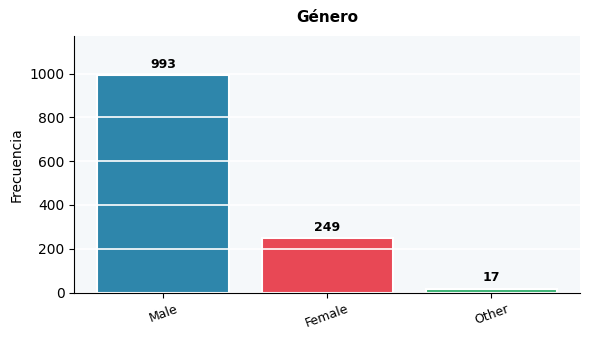

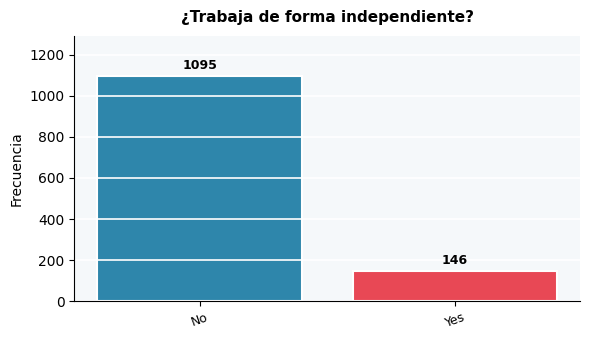

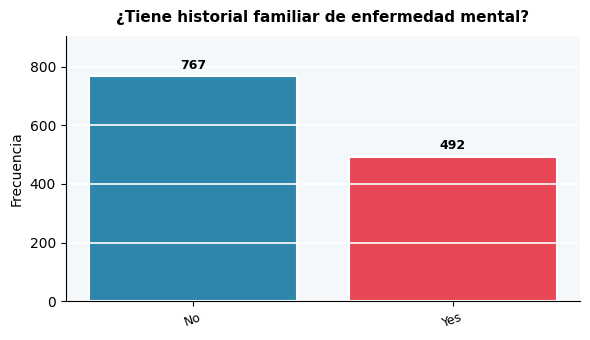

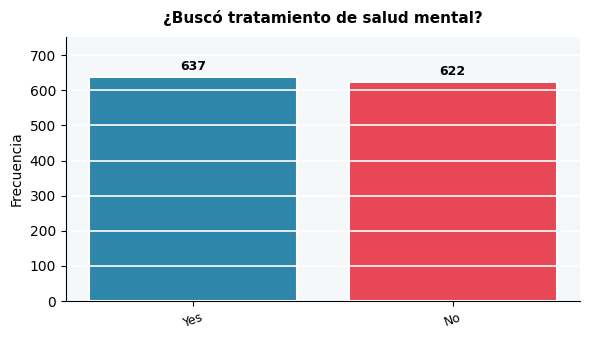

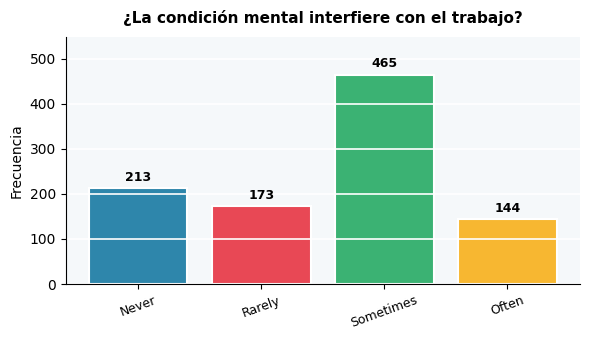

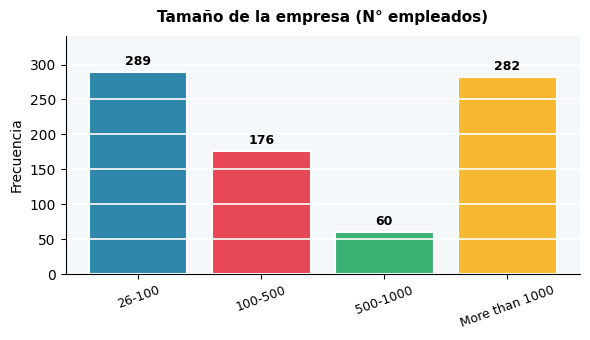

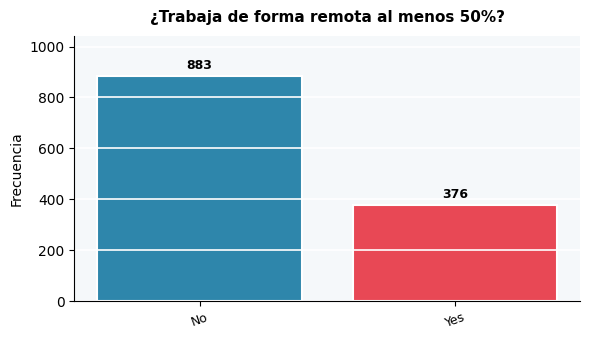

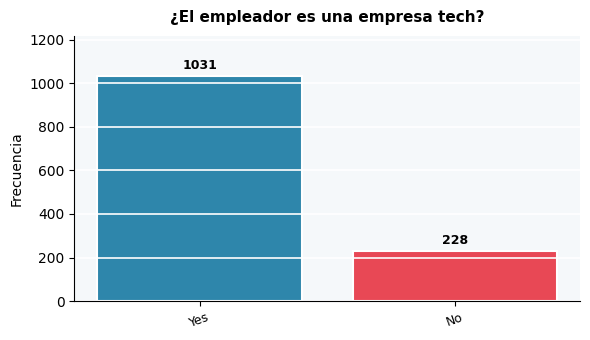

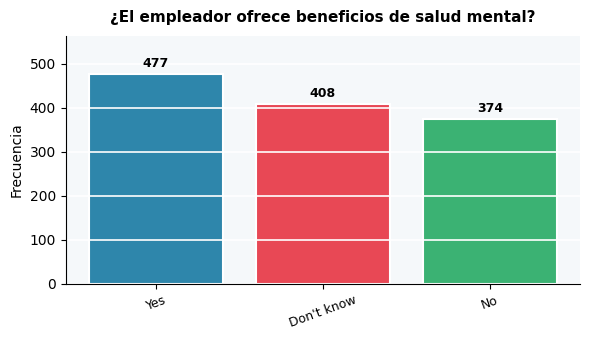

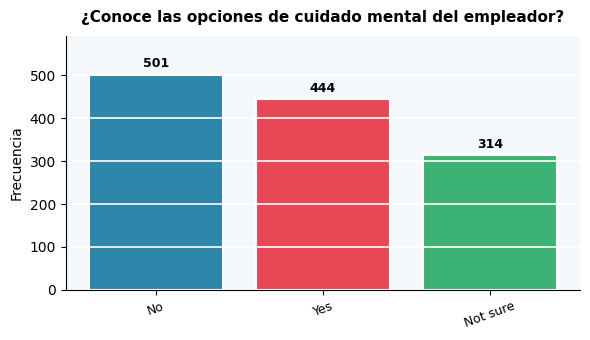

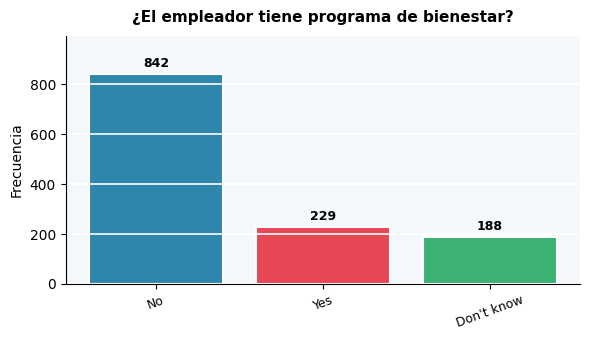

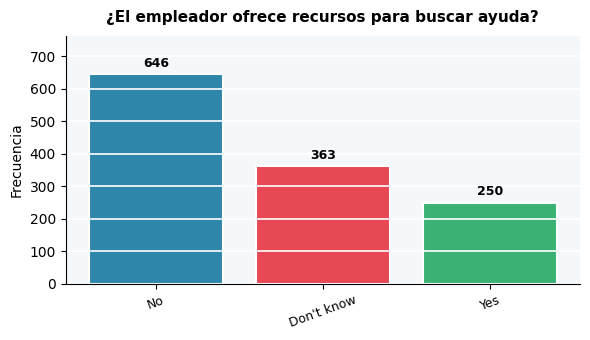

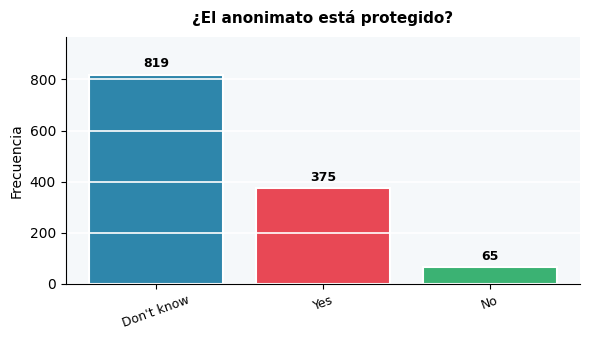

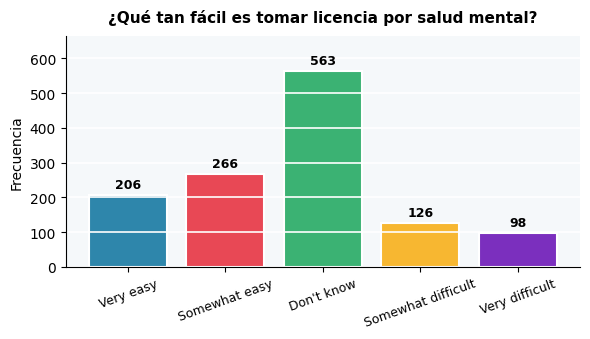

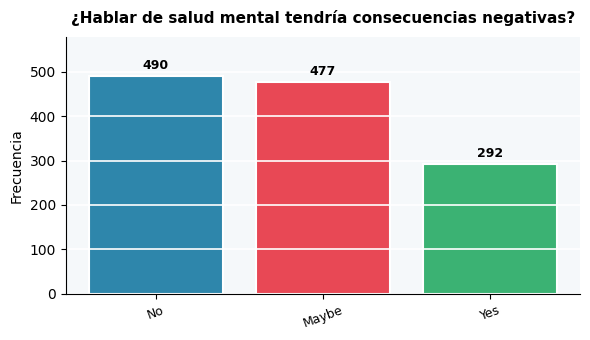

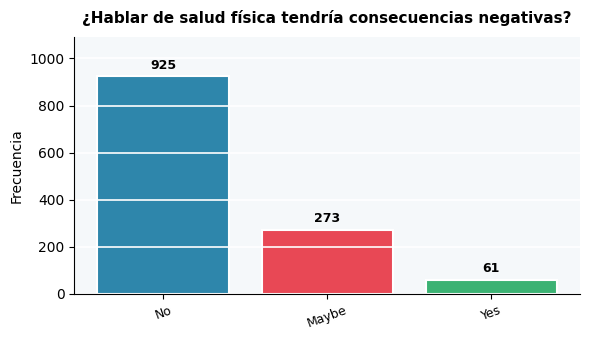

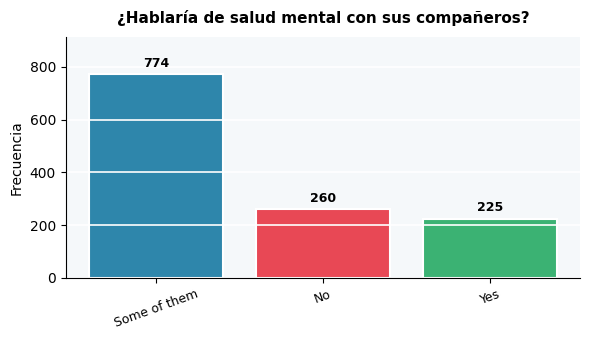

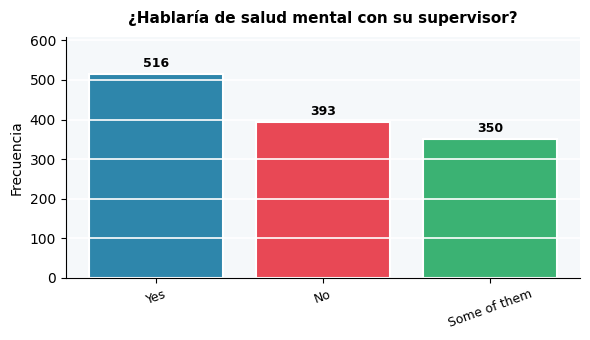

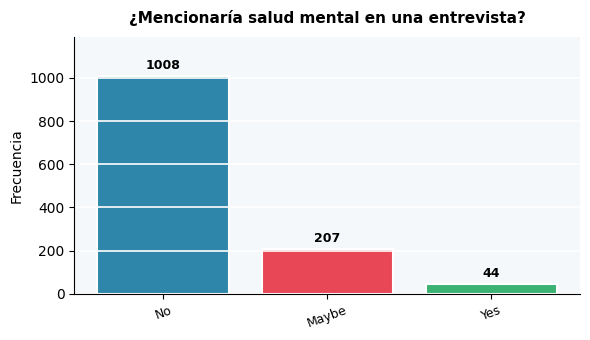

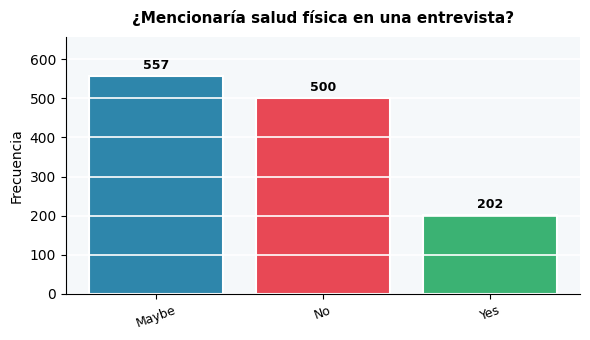

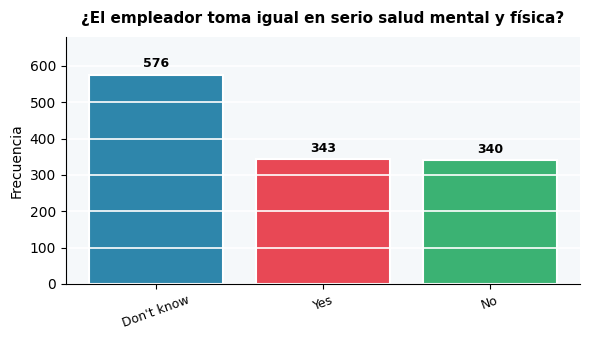

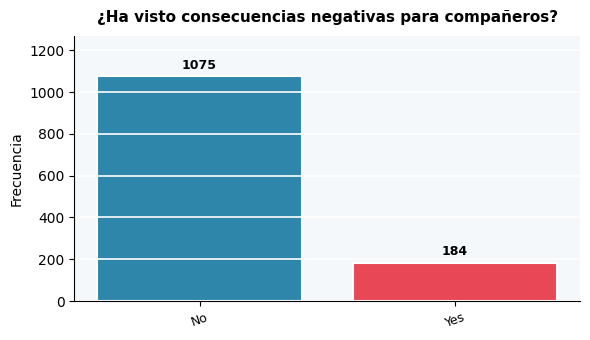

In [62]:
graficar_variables(df)

## Imputación

In [63]:
df.isnull().sum()

,0
Timestamp,0
Age,0
Gender,0
Country,0
state,515
self_employed,18
family_history,0
treatment,0
work_interfere,264
no_employees,0


In [71]:
def graficar_nulos(df, titulo="Nulos por columna"):
    nulos = df.isnull().sum()
    nulos = nulos[nulos > 0].sort_values(ascending=True)

    if len(nulos) == 0:
        print("No hay nulos en este dataframe.")
        return

    fig, ax = plt.subplots(figsize=(6, len(nulos) * 0.5 + 1))
    ax.barh(nulos.index, nulos.values, color='#E84855', edgecolor='white', linewidth=1.2)
    for i, v in enumerate(nulos.values):
        ax.text(v + 5, i, str(v), va='center', fontsize=9, fontweight='bold')
    ax.set_title(titulo, fontsize=13, fontweight='bold', pad=10)
    ax.set_xlabel('Cantidad de nulos')
    ax.set_facecolor('#F5F8FA')
    fig.patch.set_facecolor('#FFFFFF')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='x', color='white', linewidth=1.2)
    plt.tight_layout()
    plt.show()

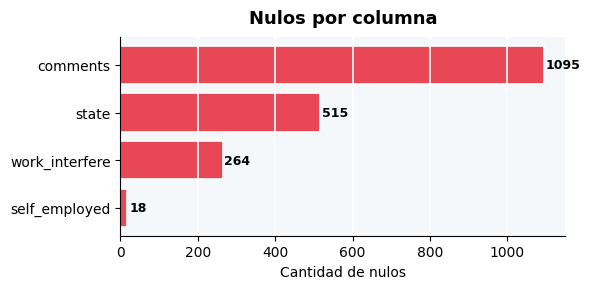

In [72]:
graficar_nulos(df)

In [73]:
df['work_interfere'] = df['work_interfere'].fillna('Unknown')
df['self_employed'] = df['self_employed'].fillna('No')
#Moda

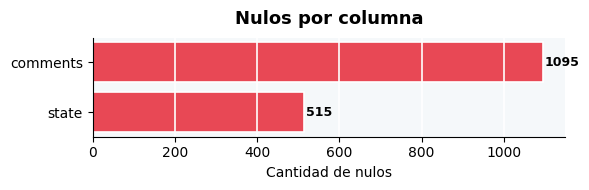

In [74]:
graficar_nulos(df)

## Eliminación de variables no predictoras

In [75]:
cols_eliminar = ['Timestamp', 'comments', 'state', 'Country']
df = df.drop(columns=[c for c in cols_eliminar if c in df.columns])

#Timestamp → no es predictiva, solo registra cuándo se envió el formulario
#comments → texto libre, 87% nulos, sin valor para el modelo
#state → 41% nulos, solo aplica para EE.UU.
#Country → 48 valores únicos, alta cardinalidad

In [76]:
df.head()

,Age,Gender,self_employed,family_history,treatment,work_interfere,no_employees,remote_work,tech_company,benefits,...,anonymity,leave,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence
0,37,Female,No,No,Yes,Often,Jun-25,No,Yes,Yes,...,Yes,Somewhat easy,No,No,Some of them,Yes,No,Maybe,Yes,No
1,44,Male,No,No,No,Rarely,More than 1000,No,No,Don't know,...,Don't know,Don't know,Maybe,No,No,No,No,No,Don't know,No
2,32,Male,No,No,No,Rarely,Jun-25,No,Yes,No,...,Don't know,Somewhat difficult,No,No,Yes,Yes,Yes,Yes,No,No
3,31,Male,No,Yes,Yes,Often,26-100,No,Yes,No,...,No,Somewhat difficult,Yes,Yes,Some of them,No,Maybe,Maybe,No,Yes
4,31,Male,No,No,No,Never,100-500,Yes,Yes,Yes,...,Don't know,Don't know,No,No,Some of them,Yes,Yes,Yes,Don't know,No


**CODIFICACIÓN DE VARIABLES**

In [77]:
encoders = {}
le = LabelEncoder()
for col in df.select_dtypes(include='object').columns:
    enc = LabelEncoder()
    df[col] = enc.fit_transform(df[col])
    encoders[col] = enc

In [78]:
df.head()

,Age,Gender,self_employed,family_history,treatment,work_interfere,no_employees,remote_work,tech_company,benefits,...,anonymity,leave,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence
0,37,0,0,0,1,1,4,0,1,2,...,2,2,1,1,1,2,1,0,2,0
1,44,1,0,0,0,2,5,0,0,0,...,0,0,0,1,0,0,1,1,0,0
2,32,1,0,0,0,2,4,0,1,1,...,0,1,1,1,2,2,2,2,1,0
3,31,1,0,1,1,1,2,0,1,1,...,1,1,2,2,1,0,0,0,1,1
4,31,1,0,0,0,0,1,1,1,2,...,0,0,1,1,1,2,2,2,0,0


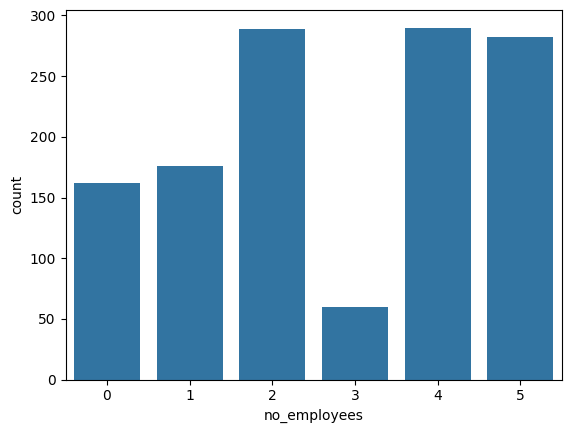

In [ ]:
sns.countplot(data=df, x='no_employees')
plt.show()

**ESCALADO Y DIVISIÓN**

In [79]:
X = df.drop('treatment', axis=1)
y = df['treatment']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y  # ← stratify: importante en datos desbalanceados
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Entrenamiento y evaluación de modelos

In [87]:
print("Nulos restantes:  ", df.isnull().sum().sum())
print("Columnas object:  ", df.select_dtypes(include='object').columns.tolist())
print("Balance objetivo:\n", df['treatment'].value_counts(normalize=True))
print("Cols constantes:  ", [c for c in df.columns if df[c].nunique() == 1])
print("Shape final:      ", df.shape)

Nulos restantes:   0
Columnas object:   []
Balance objetivo:
 treatment
1    0.505957
0    0.494043
Name: proportion, dtype: float64
Cols constantes:   []
Shape final:       (1259, 23)


## Regresión logística

In [88]:
m_log = LogisticRegression(max_iter=1000)  # ← max_iter=100 puede no converger
m_log.fit(X_train_scaled, y_train)
pred_log = m_log.predict(X_test_scaled)
acc_log = accuracy_score(y_test, pred_log)

## Árbol de Decisión


In [89]:
m_tree = DecisionTreeClassifier(max_depth=5, random_state=42)
m_tree.fit(X_train, y_train)
pred_tree = m_tree.predict(X_test)
acc_tree = accuracy_score(y_test, pred_tree)

In [91]:
print(f"Filas procesadas con éxito : {len(df)}")
print(f"Rango de Edad final        : {df['Age'].min()} a {df['Age'].max()} años")
print("-"*45)
print(f"EFICIENCIA REGRESIÓN LOGÍSTICA : {acc_log:.4f}  ({acc_log*100:.1f}%)")
print(f"EFICIENCIA ÁRBOL DE DECISIÓN   : {acc_tree:.4f}  ({acc_tree*100:.1f}%)")
print("-"*45)

# Reporte detallado para el modelo ganador
mejor_pred = pred_log if acc_log >= acc_tree else pred_tree
print("\nReporte detallado del mejor modelo:")
print(classification_report(y_test, mejor_pred, target_names=['No tratamiento', 'Con tratamiento']))

Filas procesadas con éxito : 1259
Rango de Edad final        : 18 a 72 años
---------------------------------------------
EFICIENCIA REGRESIÓN LOGÍSTICA : 0.6825  (68.3%)
EFICIENCIA ÁRBOL DE DECISIÓN   : 0.8214  (82.1%)
---------------------------------------------

Reporte detallado del mejor modelo:
                 precision    recall  f1-score   support

 No tratamiento       0.92      0.69      0.79       124
Con tratamiento       0.76      0.95      0.84       128

       accuracy                           0.82       252
      macro avg       0.84      0.82      0.82       252
   weighted avg       0.84      0.82      0.82       252



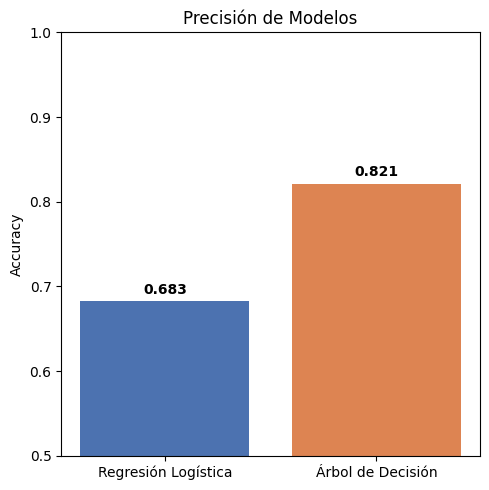

In [92]:
fig, ax = plt.subplots(figsize=(5, 5))

modelos = ['Regresión Logística', 'Árbol de Decisión']
accs    = [acc_log, acc_tree]
bars    = ax.bar(modelos, accs, color=['#4C72B0', '#DD8452'])

ax.set_ylim(0.5, 1.0)
ax.set_title('Precisión de Modelos')
ax.set_ylabel('Accuracy')

for bar, acc in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{acc:.3f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()



In [ ]:
plt.show()